# Mapping recorded marine fish richness in the Visayas: a DBSCAN proof of concept

**Draft mini data science project — real OBIS occurrence data, executed outputs.**

Research question: *Do neighboring areas with high recorded species richness form geographically coherent clusters?*

This pilot uses a **Visayas-region rectangle (122–125° E, 9–12° N)** and **Actinopterygii (ray-finned fish)**. It includes parts of Negros, Cebu, Bohol and surrounding waters, but is **not an official Central Visayas boundary, Philippine waters polygon, or nationwide inventory**. Sharks and rays are outside this taxonomic scope. A national expansion is a later step.

The pipeline is: real occurrences → cleaning → grid richness and sampling effort → high-richness cells → haversine DBSCAN → cluster composition and sensitivity. Each richness value counts distinct species recorded, not fish abundance. An area with few or no records cannot be interpreted as biologically poor.


## 1. Reproducibility and data source

The bundled snapshot lets this notebook run offline. Start Jupyter from the project folder and choose a Python environment with `pandas`, `numpy`, `matplotlib`, and `scikit-learn`; see `requirements.txt`. Run all cells in order. To obtain a fresh snapshot, run `python download_data.py` from that folder, then rerun this notebook. Live data may change, so keep the current snapshot when reproducing these results.

Source: [OBIS data access](https://obis.org/data/access/), [OBIS API](https://api.obis.org/), [OBIS manual](https://manual.obis.org/access.html). The download uses sequential cursor pagination through **all matching records**, rather than taking an arbitrary first-page sample. API query, download time, counts, and snapshot hash are recorded below and in `data/provenance.json`.

Provider datasets and licenses are retained in `data/dataset_metadata.json`, the raw JSON, and an attribution CSV. Some records have noncommercial restrictions: this is an educational analysis, and the snapshot is not relicensed by this project. Review provider terms before publishing or reusing the data. Background outline: [Natural Earth](https://www.naturalearthdata.com/about/terms-of-use/) public-domain geometry, downloaded from its [official vector repository](https://github.com/nvkelso/natural-earth-vector).


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

ROOT = Path.cwd()
assert (ROOT / 'data' / 'obis_visayas_raw.json').exists(), 'Start Jupyter in the project folder.'
DATA = ROOT / 'data'
OUTPUT = ROOT / 'outputs'
OUTPUT.mkdir(exist_ok=True)
GRID_SIZE = 0.1  # degrees; roughly 11 km north–south
RICHNESS_QUANTILE = 0.80
MIN_SAMPLES = 3  # includes the candidate cell itself
EARTH_RADIUS_KM = 6371.0088
BOUNDS = (122.0, 9.0, 125.0, 12.0)  # west, south, east, north
EPS_OVERRIDE_KM = None  # set a positive value to explore another radius
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

provenance = json.loads((DATA / 'provenance.json').read_text(encoding='utf-8'))
raw = pd.DataFrame(json.loads((DATA / 'obis_visayas_raw.json').read_text(encoding='utf-8')))
print(json.dumps(provenance, indent=2, ensure_ascii=False))
print('Raw snapshot SHA-256:', hashlib.sha256((DATA / 'obis_visayas_raw.json').read_bytes()).hexdigest())
print('Versions:', {'Python': platform.python_version(), 'pandas': pd.__version__, 'numpy': np.__version__, 'matplotlib': matplotlib.__version__, 'sklearn': sklearn.__version__})
print('Raw shape:', raw.shape)
print('Available fields:', ', '.join(raw.columns))


{
  "source": "Ocean Biodiversity Information System (OBIS)",
  "endpoint": "https://api.obis.org/v3/occurrence",
  "query": {
    "scientificname": "Actinopterygii",
    "geometry": "POLYGON ((122 9, 125 9, 125 12, 122 12, 122 9))",
    "fields": "id,occurrenceID,dataset_id,datasetName,scientificName,species,speciesid,genus,family,class,decimalLatitude,decimalLongitude,year,minimumDepthInMeters,maximumDepthInMeters,marine,absence,dropped,flags,license,rightsHolder,accessRights,basisOfRecord,coordinateUncertaintyInMeters"
  },
  "query_example_url": "https://api.obis.org/v3/occurrence?scientificname=Actinopterygii&geometry=POLYGON+%28%28122+9%2C+125+9%2C+125+12%2C+122+12%2C+122+9%29%29&fields=id%2CoccurrenceID%2Cdataset_id%2CdatasetName%2CscientificName%2Cspecies%2Cspeciesid%2Cgenus%2Cfamily%2Cclass%2CdecimalLatitude%2CdecimalLongitude%2Cyear%2CminimumDepthInMeters%2CmaximumDepthInMeters%2Cmarine%2Cabsence%2Cdropped%2Cflags%2Clicense%2CrightsHolder%2CaccessRights%2CbasisOfRecord%2Ccoor

In [2]:
attribution = raw.groupby('dataset_id').agg(records=('id', 'size')).reset_index()
for field in ['datasetName', 'license', 'rightsHolder', 'accessRights']:
    if field in raw:
        values = raw.groupby('dataset_id')[field].agg(lambda s: ' | '.join(sorted(set(s.dropna().astype(str)))))
        attribution[field] = attribution['dataset_id'].map(values)
attribution['source_url'] = 'https://obis.org/dataset/' + attribution['dataset_id']
attribution.to_csv(DATA / 'dataset_attribution.csv', index=False)
print(attribution.sort_values('records', ascending=False).to_string(index=False))


                          dataset_id  records                                                                                                                                           datasetName                                                                                                                                             license                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

## 2. Clean records and audit exclusions

We retain explicit marine presences with usable coordinates and an identified species. This uses OBIS's taxonomic `speciesid` where available, with a species-name fallback; it does not count unidentified genera as species. We remove repeated OBIS IDs and repeated provider occurrence IDs within a dataset. We **keep** separate records of the same species at the same coordinates because they may represent legitimate surveys or specimens. Duplicates across different providers cannot always be resolved.

The marine flag describes the taxon's marine association; it does not prove that a record lies at sea. **This field-selected API snapshot did not return a `flags` column, so no OBIS flag-based exclusions were applied.** Coordinate uncertainty and record types are inspected below. Coastal and apparently land-based records remain a limitation requiring coordinate and habitat checks before a final ecological claim. Some cell centers may fall on land even when the underlying records are coastal; a terrestrial location on the occurrence-point map still needs review. Missing or invalid depth does not disqualify a usable richness record; invalid depths are treated as missing. The cleaning audit makes each removal visible.


In [3]:
df = raw.copy()
audit = []
def keep(mask, reason):
    global df
    before = len(df)
    df = df.loc[mask].copy()
    audit.append({'rule': reason, 'removed': before - len(df), 'remaining': len(df)})

for col in ['decimalLatitude', 'decimalLongitude', 'speciesid', 'year', 'minimumDepthInMeters', 'maximumDepthInMeters']:
    if col not in df:
        df[col] = np.nan
    df[col] = pd.to_numeric(df[col], errors='coerce')
keep(df.decimalLatitude.between(-90, 90) & df.decimalLongitude.between(-180, 180), 'Valid, nonmissing coordinates')
w, s, e, n = BOUNDS
keep(df.decimalLongitude.between(w, e) & df.decimalLatitude.between(s, n), 'Inside study rectangle')
keep(df.get('absence', pd.Series(False, index=df.index)).fillna(False).eq(False), 'Presence records only')
keep(df.get('dropped', pd.Series(False, index=df.index)).fillna(False).eq(False), 'Exclude OBIS dropped records')
keep(df.get('marine', pd.Series(False, index=df.index)).eq(True), 'Taxon explicitly flagged marine')
df['species'] = df.get('species', pd.Series(pd.NA, index=df.index)).astype('string').str.strip()
keep(df.species.notna() & df.species.ne(''), 'Identified species required')
keep(~df['id'].duplicated(), 'Unique OBIS record ID')
if 'occurrenceID' in df:
    provider_id = df['occurrenceID'].astype('string').str.strip()
    repeated = provider_id.notna() & provider_id.ne('') & df.duplicated(['dataset_id', 'occurrenceID'])
    keep(~repeated, 'Unique nonempty provider occurrence ID within dataset')
df['species_key'] = ['aphia:' + str(int(i)) if pd.notna(i) else 'name:' + name for i, name in zip(df.speciesid, df.species)]
df.loc[~df.year.between(1500, pd.Timestamp(provenance['retrieved_utc']).year), 'year'] = np.nan
for col in ['minimumDepthInMeters', 'maximumDepthInMeters']:
    df.loc[~df[col].between(0, 11000), col] = np.nan
reversed_depth = df.minimumDepthInMeters > df.maximumDepthInMeters
df.loc[reversed_depth, ['minimumDepthInMeters', 'maximumDepthInMeters']] = np.nan
df['depth_m'] = df[['minimumDepthInMeters', 'maximumDepthInMeters']].mean(axis=1)
cleaning_audit = pd.DataFrame(audit)
cleaning_audit.to_csv(OUTPUT / 'cleaning_audit.csv', index=False)
print(cleaning_audit.to_string(index=False))
print('Depth ranges invalidated:', int(reversed_depth.sum()))
print('Species-name fallbacks:', int(df.speciesid.isna().sum()))
print('Top retained OBIS quality flags:')
print(df['flags'].explode().value_counts().head(12).to_string() if 'flags' in df else 'No flags field')
if 'coordinateUncertaintyInMeters' in df:
    uncertainty = pd.to_numeric(df.coordinateUncertaintyInMeters, errors='coerce')
    print(f'Coordinate uncertainty supplied for {100*uncertainty.notna().mean():.1f}% of retained records; {int((uncertainty > 10000).sum())} exceed 10 km.')
if 'basisOfRecord' in df:
    print('Record types:')
    print(df.basisOfRecord.value_counts(dropna=False).to_string())
cols = ['id', 'occurrenceID', 'dataset_id', 'species', 'species_key', 'genus', 'family', 'class', 'decimalLatitude', 'decimalLongitude', 'year', 'depth_m']
df[[c for c in cols if c in df]].to_csv(DATA / 'obis_visayas_clean.csv', index=False)
assert len(df) > 0 and df.species_key.notna().all()
assert df['id'].is_unique


                                                 rule  removed  remaining
                        Valid, nonmissing coordinates        0      42032
                               Inside study rectangle        0      42032
                                Presence records only        0      42032
                         Exclude OBIS dropped records        0      42032
                      Taxon explicitly flagged marine      181      41851
                          Identified species required     2986      38865
                                Unique OBIS record ID        0      38865
Unique nonempty provider occurrence ID within dataset        0      38865
Depth ranges invalidated: 3
Species-name fallbacks: 0
Top retained OBIS quality flags:
No flags field
Coordinate uncertainty supplied for 54.3% of retained records; 2048 exceed 10 km.
Record types:
basisOfRecord
HumanObservation     23266
PreservedSpecimen    15494
preservedspecimen      104
Occurrence               1


## 3. Describe the snapshot before clustering

These are records pooled across contributing sources and years. Family bars measure **record frequency**, not fish abundance. Annual counts indicate how the database was sampled and cannot establish a biological trend. Depth is optional because its completeness may be poor.


clean_records             38865.00
recorded_species           2237.00
recorded_families           179.00
contributing_datasets        28.00
years_with_records           73.00
earliest_year              1885.00
latest_year                2016.00
year_completeness_pct        41.77
depth_completeness_pct       10.85


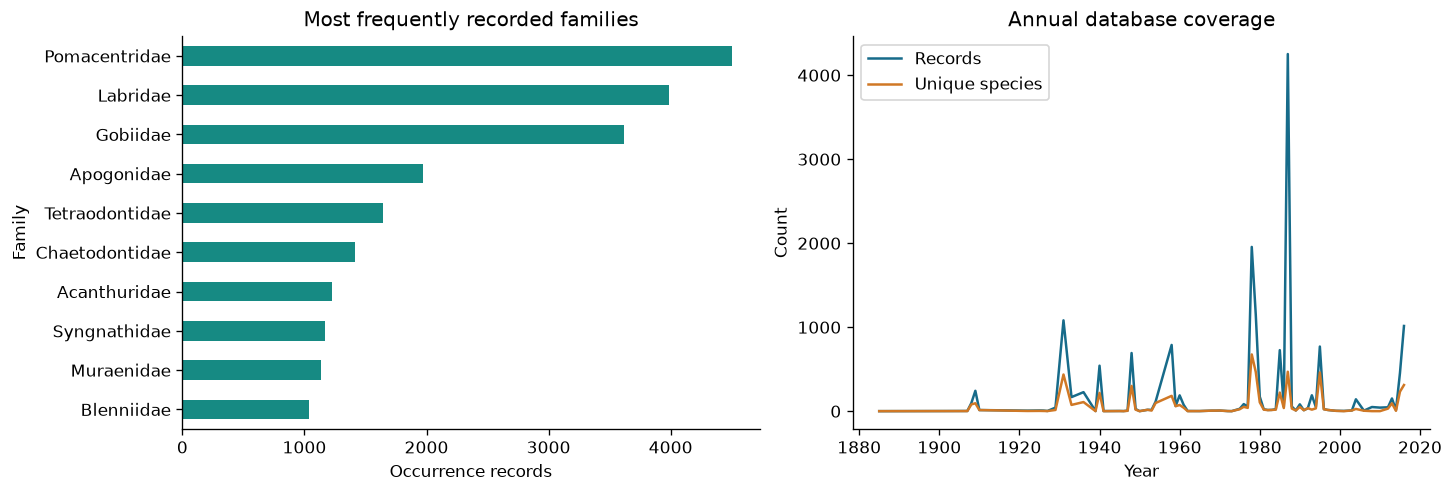

In [4]:
summary = pd.Series({'clean_records': len(df), 'recorded_species': df.species_key.nunique(), 'recorded_families': df.family.nunique(), 'contributing_datasets': df.dataset_id.nunique(), 'years_with_records': df.year.nunique(), 'earliest_year': df.year.min(), 'latest_year': df.year.max(), 'year_completeness_pct': 100 * df.year.notna().mean(), 'depth_completeness_pct': 100 * df.depth_m.notna().mean()})
print(summary.round(2).to_string())
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
df.family.value_counts().head(10).sort_values().plot.barh(ax=axes[0], color='#168a83')
axes[0].set(title='Most frequently recorded families', xlabel='Occurrence records', ylabel='Family')
annual = df.dropna(subset=['year']).groupby('year').agg(records=('id', 'size'), species=('species_key', 'nunique'))
axes[1].plot(annual.index, annual.records, label='Records', color='#176b8a')
axes[1].plot(annual.index, annual.species, label='Unique species', color='#d07825')
axes[1].set(title='Annual database coverage', xlabel='Year', ylabel='Count')
axes[1].legend()
fig.savefig(OUTPUT / '01_families_and_years.png', bbox_inches='tight')
plt.show()


## 4. Aggregate records into geographic grid cells

Use a fixed grid origin at the southwest corner of the rectangle. The 0.1° pilot grid is about 11 km north–south; longitude widths vary with latitude. It is a convenient exploratory scale, not an optimized ecological unit. We test 0.25° and 0.5° grids later. Only **occupied cells** enter the richness distribution; unsampled cells have unknown richness.

Within a cell, richness is the number of unique species identifiers. Additional columns summarize records, families, datasets and sampling years. Cluster-level richness must be recomputed from the union of species across cells, since summing cell richness would count some species more than once.


In [5]:
def aggregate_grid(records, step):
    tagged = records.copy()
    west, south, east, north = BOUNDS
    nx, ny = int(np.ceil((east-west)/step)), int(np.ceil((north-south)/step))
    tagged['ix'] = np.floor((tagged.decimalLongitude-west)/step).astype(int).clip(0, nx-1)
    tagged['iy'] = np.floor((tagged.decimalLatitude-south)/step).astype(int).clip(0, ny-1)
    tagged['cell_id'] = tagged.ix.astype(str) + ':' + tagged.iy.astype(str)
    grid = tagged.groupby('cell_id').agg(ix=('ix', 'first'), iy=('iy', 'first'), observation_count=('id', 'size'), unique_species=('species_key', 'nunique'), unique_families=('family', 'nunique'), years_sampled=('year', 'nunique'), dataset_count=('dataset_id', 'nunique'), median_depth_m=('depth_m', 'median')).reset_index()
    grid['center_lon'] = west + (grid.ix + 0.5) * step
    grid['center_lat'] = south + (grid.iy + 0.5) * step
    grid['species_per_record'] = grid.unique_species / grid.observation_count
    assert grid.observation_count.sum() == len(records)
    assert (grid.unique_species <= grid.observation_count).all()
    return tagged, grid

tagged, grid = aggregate_grid(df, GRID_SIZE)
threshold = grid.unique_species.quantile(RICHNESS_QUANTILE)
candidates = grid.loc[grid.unique_species >= threshold].copy()
print(f'{len(grid)} occupied cells; richness threshold = {threshold:.2f}; {len(candidates)} candidate cells ({100*len(candidates)/len(grid):.1f}%).')
print('Ties at the threshold can make the selected fraction exceed 20%.')
print(grid.sort_values('unique_species', ascending=False).head(12).to_string(index=False))
grid.to_csv(OUTPUT / 'grid_metrics.csv', index=False)


358 occupied cells; richness threshold = 31.00; 73 candidate cells (20.4%).
Ties at the threshold can make the selected fraction exceed 20%.
cell_id  ix  iy  observation_count  unique_species  unique_families  years_sampled  dataset_count  median_depth_m  center_lon  center_lat  species_per_record
   13:3  13   3               2334             643              105             30             10           0.915      123.35        9.35            0.275493
   12:1  12   1               5050             590               70              2              4           5.790      123.25        9.15            0.116832
   13:9  13   9               3712             564               70              2              7          21.000      123.35        9.95            0.151940
   12:0  12   0               1614             451               69             10             12           6.000      123.25        9.05            0.279430
  21:23  21  23               1905             416               67  

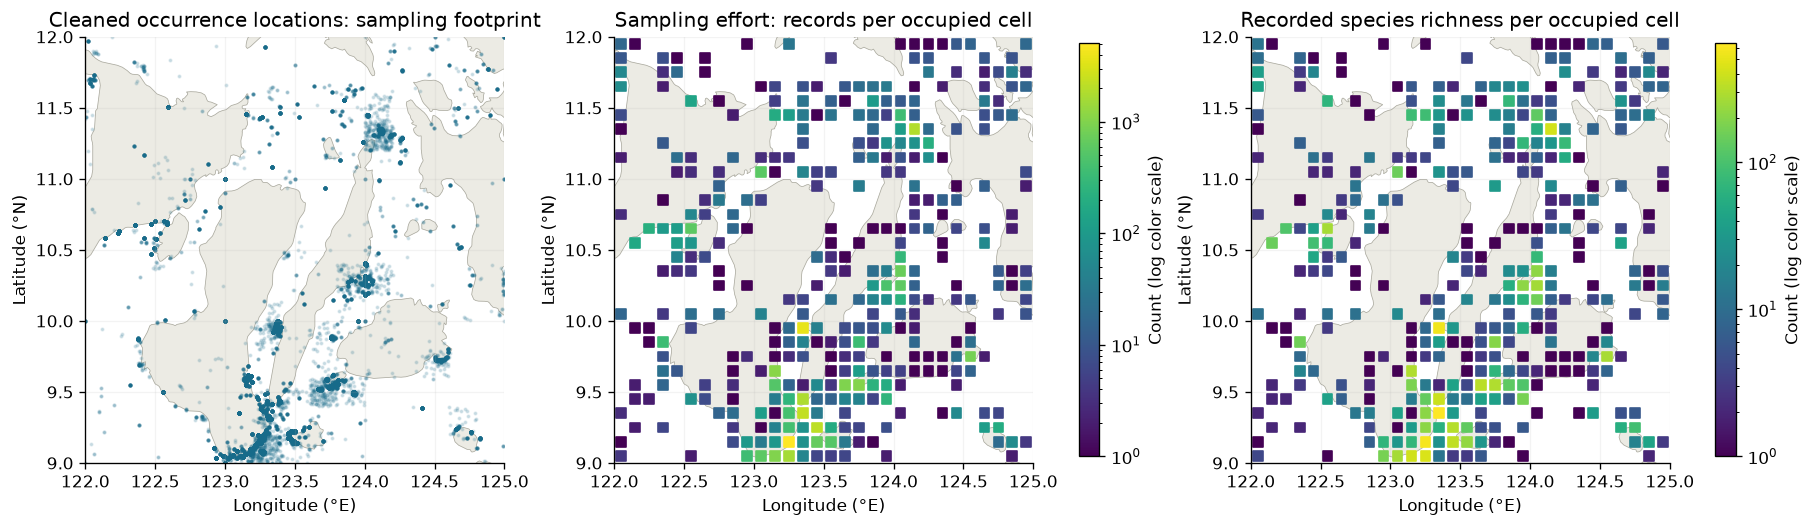

In [6]:
outline = json.loads((DATA / 'philippines_outline.geojson').read_text(encoding='utf-8'))
def map_background(ax):
    for feature in outline['features']:
        geom = feature['geometry']
        polygons = geom['coordinates'] if geom['type'] == 'MultiPolygon' else [geom['coordinates']]
        for polygon in polygons:
            ring = np.array(polygon[0])
            ax.fill(ring[:, 0], ring[:, 1], facecolor='#ecebe4', edgecolor='#aaa99e', linewidth=0.45, zorder=0)
    ax.set(xlim=(BOUNDS[0], BOUNDS[2]), ylim=(BOUNDS[1], BOUNDS[3]), xlabel='Longitude (°E)', ylabel='Latitude (°N)')
    ax.set_aspect(1/np.cos(np.deg2rad(10.5)))
    ax.grid(alpha=0.15)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout='constrained')
for ax in axes:
    map_background(ax)
axes[0].scatter(df.decimalLongitude, df.decimalLatitude, s=2, alpha=0.15, color='#176b8a', rasterized=True)
axes[0].set_title('Cleaned occurrence locations: sampling footprint')
for ax, column, title in [(axes[1], 'observation_count', 'Sampling effort: records per occupied cell'), (axes[2], 'unique_species', 'Recorded species richness per occupied cell')]:
    points = ax.scatter(grid.center_lon, grid.center_lat, c=grid[column], norm=matplotlib.colors.LogNorm(vmin=1, vmax=max(2, grid[column].max())), s=34, marker='s', cmap='viridis')
    ax.set_title(title)
    fig.colorbar(points, ax=ax, label='Count (log color scale)', shrink=0.7)
fig.savefig(OUTPUT / '02_sampling_and_richness_maps.png', bbox_inches='tight')
plt.show()


## 5. Select high-richness cells and examine sampling effort

The candidate rule is **at or above the 80th percentile of richness among occupied cells**. This relative definition makes the pilot transparent, but it is not a significance test and does not establish an ecological hotspot. The distribution is plotted with its threshold. The scatter plot checks whether recorded richness increases with recorded sampling; rank correlation describes association without implying causality.

Species per record is an exploratory ratio only. It can be high in tiny samples and is not an official biodiversity index or an effort correction. Coverage-based rarefaction would require further justification and checks on sampling units.


Spearman rank correlation: 0.969
High-richness candidates with the fewest records (exploratory, not adjusted richness):
cell_id  unique_species  observation_count  dataset_count  years_sampled  species_per_record
   14:3              33                 34              1              7            0.970588
  17:19              33                 35              1              2            0.942857
   14:9              31                 40              1              0            0.775000
   11:2              34                 44              4              1            0.772727
   13:8              36                 45              2              1            0.800000
   16:4              40                 45              2              1            0.888889
   17:4              38                 45              1              0            0.844444
   4:14              47                 47              1              1            1.000000


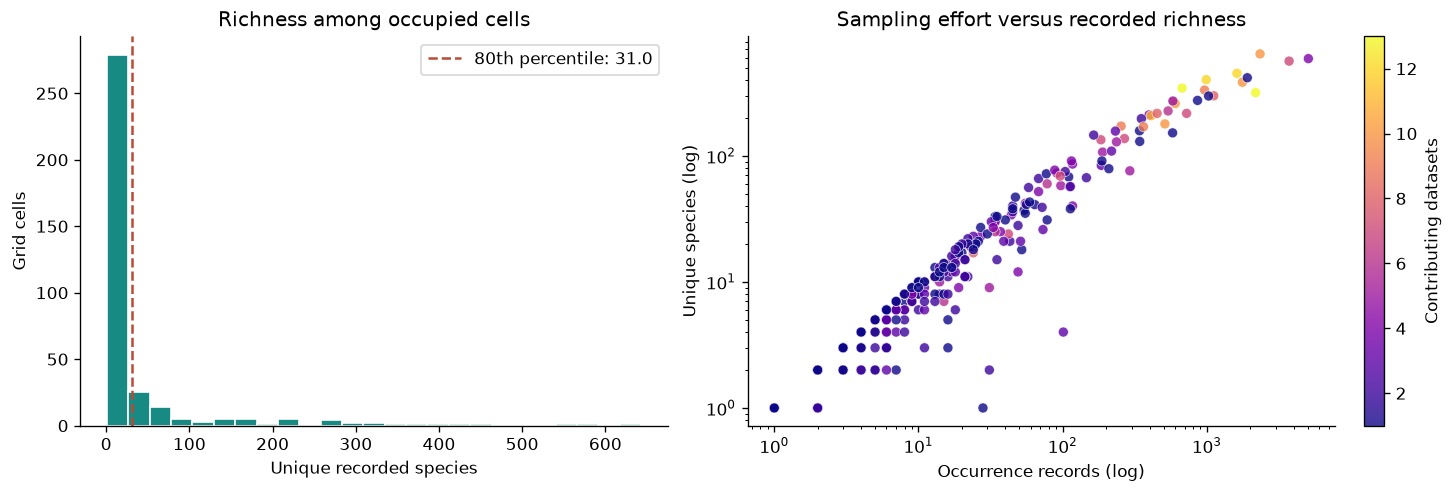

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
axes[0].hist(grid.unique_species, bins=25, color='#168a83', edgecolor='white')
axes[0].axvline(threshold, color='#ba4b35', linestyle='--', label=f'80th percentile: {threshold:.1f}')
axes[0].set(title='Richness among occupied cells', xlabel='Unique recorded species', ylabel='Grid cells')
axes[0].legend()
pts = axes[1].scatter(grid.observation_count, grid.unique_species, c=grid.dataset_count, cmap='plasma', alpha=0.8, edgecolors='white', linewidth=0.4)
axes[1].set(xscale='log', yscale='log', title='Sampling effort versus recorded richness', xlabel='Occurrence records (log)', ylabel='Unique species (log)')
fig.colorbar(pts, ax=axes[1], label='Contributing datasets')
rho = grid.observation_count.rank().corr(grid.unique_species.rank())
print(f'Spearman rank correlation: {rho:.3f}')
print('High-richness candidates with the fewest records (exploratory, not adjusted richness):')
print(candidates.sort_values('observation_count').head(8)[['cell_id','unique_species','observation_count','dataset_count','years_sampled','species_per_record']].to_string(index=False))
fig.savefig(OUTPUT / '03_threshold_and_sampling_bias.png', bbox_inches='tight')
plt.show()


## 6. Choose a DBSCAN distance and inspect sensitivity

DBSCAN groups neighboring candidate cells, permits irregular shapes and marks isolated cells as noise. We cluster **cell centers**, not individual observation locations. Input order is latitude then longitude; radians and haversine distance give great-circle distances. `eps` is converted from kilometers to radians using the mean Earth radius.

For `min_samples=3`, the sorted distance to the third nearest point **including the point itself** gives a distance diagnostic consistent with DBSCAN's definition. A simple maximum departure from the endpoint chord supplies a draft elbow suggestion. It is a heuristic that can fail when there is no clear elbow; inspect the plot and the sensitivity table. With fewer than three candidate cells, the pilot needs a different scope or grid. The percentile, grid size, and neighbor requirement are exploratory choices, not tuned against independent ecological labels.


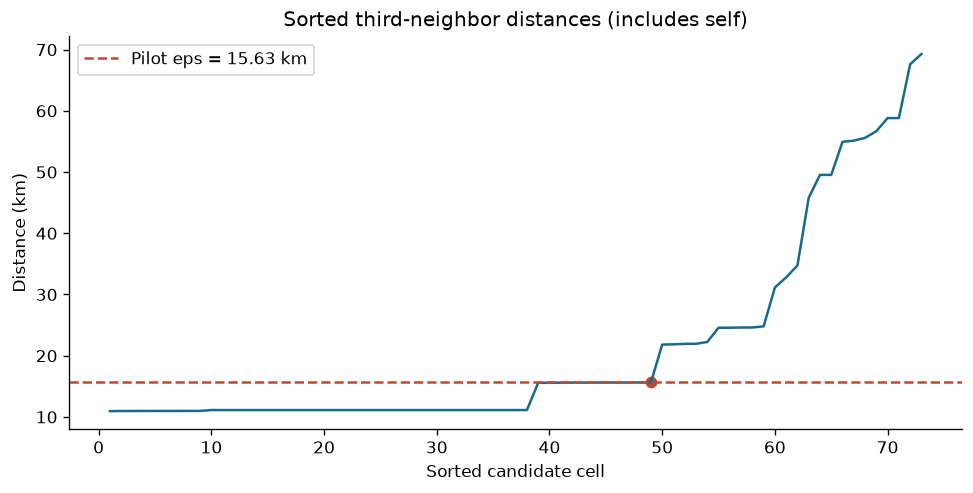

Elbow suggestion: 15.63 km; actual pilot eps: 15.63 km
  eps_km  min_samples  clusters  noise_cells  clustered_cells
15.00000            3         6           25               48
15.00000            4         4           42               31
15.00000            5         4           57               16
15.62671            3         7           17               56
15.62671            4         5           26               47
15.62671            5         5           28               45
25.00000            3         5           11               62
25.00000            4         5           14               59
25.00000            5         4           19               54
40.00000            3         4           10               63
40.00000            4         4           10               63
40.00000            5         3           14               59


In [8]:
assert len(candidates) >= MIN_SAMPLES, 'Too few candidate cells for this min_samples.'
coords_rad = np.deg2rad(candidates[['center_lat', 'center_lon']].to_numpy())
distances, _ = NearestNeighbors(n_neighbors=MIN_SAMPLES, metric='haversine', algorithm='ball_tree').fit(coords_rad).kneighbors(coords_rad)
kdist_km = np.sort(distances[:, -1] * EARTH_RADIUS_KM)
x = np.linspace(0, 1, len(kdist_km))
y = (kdist_km - kdist_km.min()) / max(float(np.ptp(kdist_km)), 1e-12)
knee_index = int(np.argmax(x - y))
suggested_eps = max(0.1, float(kdist_km[knee_index]))
EPS_KM = suggested_eps if EPS_OVERRIDE_KM is None else float(EPS_OVERRIDE_KM)
assert EPS_KM > 0
fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
ax.plot(np.arange(1, len(kdist_km)+1), kdist_km, color='#176b8a')
ax.axhline(EPS_KM, color='#ba4b35', linestyle='--', label=f'Pilot eps = {EPS_KM:.2f} km')
ax.scatter(knee_index+1, suggested_eps, c='#ba4b35')
ax.set(title='Sorted third-neighbor distances (includes self)', xlabel='Sorted candidate cell', ylabel='Distance (km)')
ax.legend()
fig.savefig(OUTPUT / '04_k_distance.png', bbox_inches='tight')
plt.show()

def run_dbscan(cells, eps_km, min_samples):
    if len(cells) == 0:
        return np.array([], dtype=int)
    radians = np.deg2rad(cells[['center_lat', 'center_lon']].to_numpy())
    return DBSCAN(eps=eps_km/EARTH_RADIUS_KM, min_samples=min_samples, metric='haversine', algorithm='ball_tree').fit_predict(radians)

def label_stats(labels):
    return {'clusters': len(set(labels) - {-1}), 'noise_cells': int((labels == -1).sum()), 'clustered_cells': int((labels >= 0).sum())}

candidates['cluster'] = run_dbscan(candidates, EPS_KM, MIN_SAMPLES)
trials = []
for radius in sorted(set([15.0, 25.0, 40.0, round(EPS_KM, 5)])):
    for minimum in [3, 4, 5]:
        labels = run_dbscan(candidates, radius, minimum)
        trials.append({'eps_km': radius, 'min_samples': minimum, **label_stats(labels)})
sensitivity = pd.DataFrame(trials)
print(f'Elbow suggestion: {suggested_eps:.2f} km; actual pilot eps: {EPS_KM:.2f} km')
print(sensitivity.to_string(index=False))
sensitivity.to_csv(OUTPUT / 'dbscan_parameter_sensitivity.csv', index=False)
candidates.to_csv(OUTPUT / 'candidate_cell_clusters.csv', index=False)


## 7. Map and characterize clusters

The map shows labels for the pilot radius. Label numbers are arbitrary identifiers. Grey crosses are high-richness candidates classified as noise; pale dots are other occupied cells. Noise means spatial isolation or insufficient nearby candidates under these settings, not low biodiversity.

Cluster richness is the distinct species union in **candidate cells assigned to that cluster**, not a sum of cell richness and not all records in a polygon surrounding the cluster. The analysis uses the same definition for records and family composition. Family proportions summarize recorded occurrences and may be affected by dataset methods.


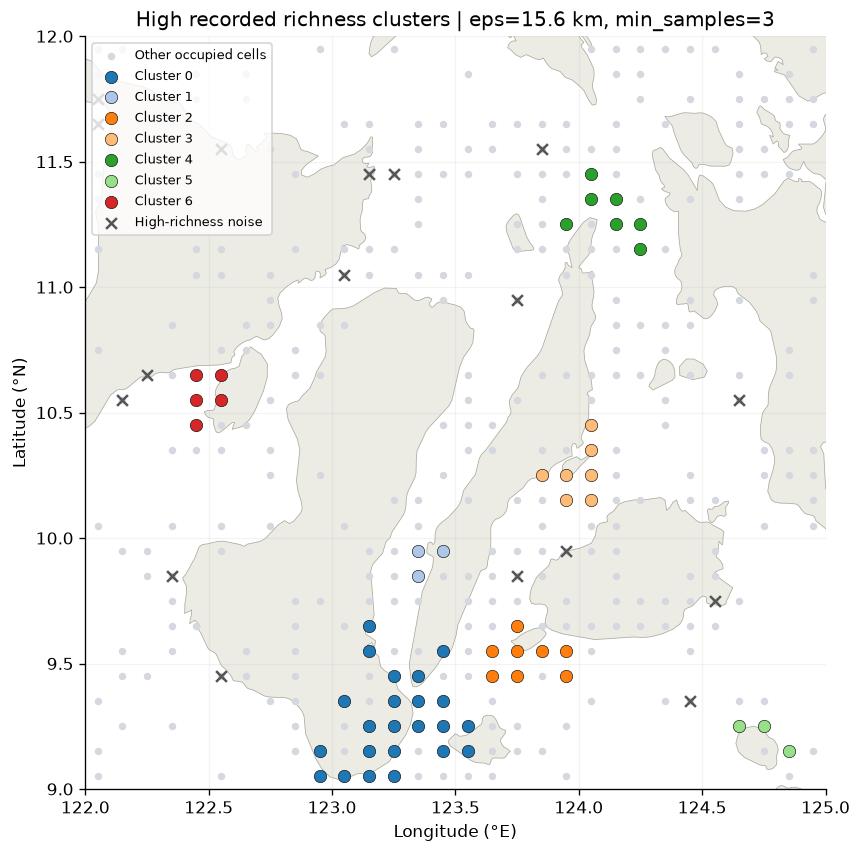

Cluster summaries (species union, not summed richness):
         total_records  unique_species  unique_families  datasets  years_sampled  median_depth_m  grid_cells  mean_cell_richness
cluster                                                                                                                         
0                19484            1524              129        16             51            2.44          23              231.00
1                 3797             575               73         7              2           21.00           3              210.33
2                 2869             538               79        13              8           24.00           8              148.00
3                 2466             579              104        15             21           30.00           7              150.14
4                 2791             521               93         5              3          333.00           7              119.57
5                  359             163   

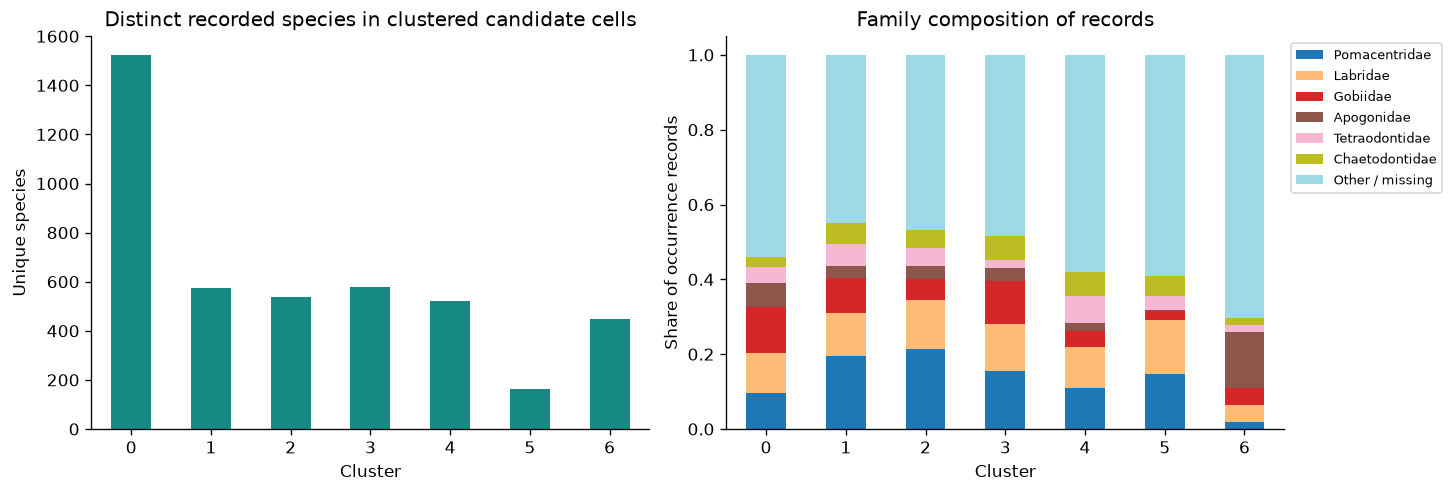

In [9]:
fig, ax = plt.subplots(figsize=(8, 7), layout='constrained')
map_background(ax)
ax.scatter(grid.center_lon, grid.center_lat, s=12, color='#d5d9df', label='Other occupied cells')
cluster_ids = sorted(set(candidates.cluster) - {-1})
palette = plt.get_cmap('tab20')
for i, cluster_id in enumerate(cluster_ids):
    part = candidates[candidates.cluster == cluster_id]
    ax.scatter(part.center_lon, part.center_lat, s=55, color=palette(i % 20), edgecolors='black', linewidth=0.35, label=f'Cluster {cluster_id}')
noise = candidates[candidates.cluster == -1]
if len(noise):
    ax.scatter(noise.center_lon, noise.center_lat, s=42, color='#555555', marker='x', label='High-richness noise')
ax.set_title(f'High recorded richness clusters | eps={EPS_KM:.1f} km, min_samples={MIN_SAMPLES}')
ax.legend(loc='upper left', fontsize=8)
fig.savefig(OUTPUT / '05_dbscan_cluster_map.png', bbox_inches='tight')
plt.show()

cluster_records = tagged.merge(candidates[['cell_id', 'cluster']], on='cell_id', how='inner', validate='many_to_one')
cluster_summary = cluster_records[cluster_records.cluster >= 0].groupby('cluster').agg(total_records=('id', 'size'), unique_species=('species_key', 'nunique'), unique_families=('family', 'nunique'), datasets=('dataset_id', 'nunique'), years_sampled=('year', 'nunique'), median_depth_m=('depth_m', 'median'))
cell_summary = candidates[candidates.cluster >= 0].groupby('cluster').agg(grid_cells=('cell_id', 'size'), mean_cell_richness=('unique_species', 'mean'))
cluster_summary = cluster_summary.join(cell_summary)
cluster_summary.to_csv(OUTPUT / 'cluster_summary.csv')
print('Cluster summaries (species union, not summed richness):')
print(cluster_summary.round(2).to_string())
print('Noise candidate cells:', len(noise))
if len(cluster_summary):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
    cluster_summary.unique_species.plot.bar(ax=axes[0], color='#168a83', rot=0)
    axes[0].set(title='Distinct recorded species in clustered candidate cells', xlabel='Cluster', ylabel='Unique species')
    families = cluster_records.loc[cluster_records.cluster >= 0, 'family'].value_counts().head(6).index
    composition = pd.crosstab(cluster_records.loc[cluster_records.cluster >= 0, 'cluster'], cluster_records.loc[cluster_records.cluster >= 0, 'family'])
    totals = cluster_records.loc[cluster_records.cluster >= 0].groupby('cluster').size()
    shares = composition.reindex(columns=families, fill_value=0).div(totals, axis=0)
    shares['Other / missing'] = (1 - shares.sum(axis=1)).clip(lower=0)
    shares.plot.bar(stacked=True, ax=axes[1], colormap='tab20', rot=0)
    axes[1].set(title='Family composition of records', xlabel='Cluster', ylabel='Share of occurrence records')
    axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
    shares.to_csv(OUTPUT / 'cluster_family_record_shares.csv')
    fig.savefig(OUTPUT / '06_cluster_richness_and_composition.png', bbox_inches='tight')
    plt.show()
else:
    print('No spatial cluster at these settings. That is a valid outcome; inspect sensitivity instead of forcing clusters.')


## 8. Check grid and threshold dependence

The table below changes the grid scale and the candidate percentile while holding the pilot `eps` and `min_samples` fixed. This isolates those changes, but a wider grid also changes spacing, so these comparisons do not imply that one setting is optimal. The charts summarize cluster counts; matching the membership and geography of clusters across settings would be a stronger stability assessment for the final project.


 grid_degrees  quantile  occupied_cells  richness_cutoff  candidate_cells  clusters  noise_cells  clustered_cells
         0.10       0.7             358             15.0              111         9           28               83
         0.10       0.8             358             31.0               73         7           17               56
         0.10       0.9             358             91.0               37         3           12               25
         0.25       0.7             127             40.6               38         0           38                0
         0.25       0.8             127            118.0               26         0           26                0
         0.25       0.9             127            256.2               13         0           13                0
         0.50       0.7              36            270.0               11         0           11                0
         0.50       0.8              36            375.0                8         0     

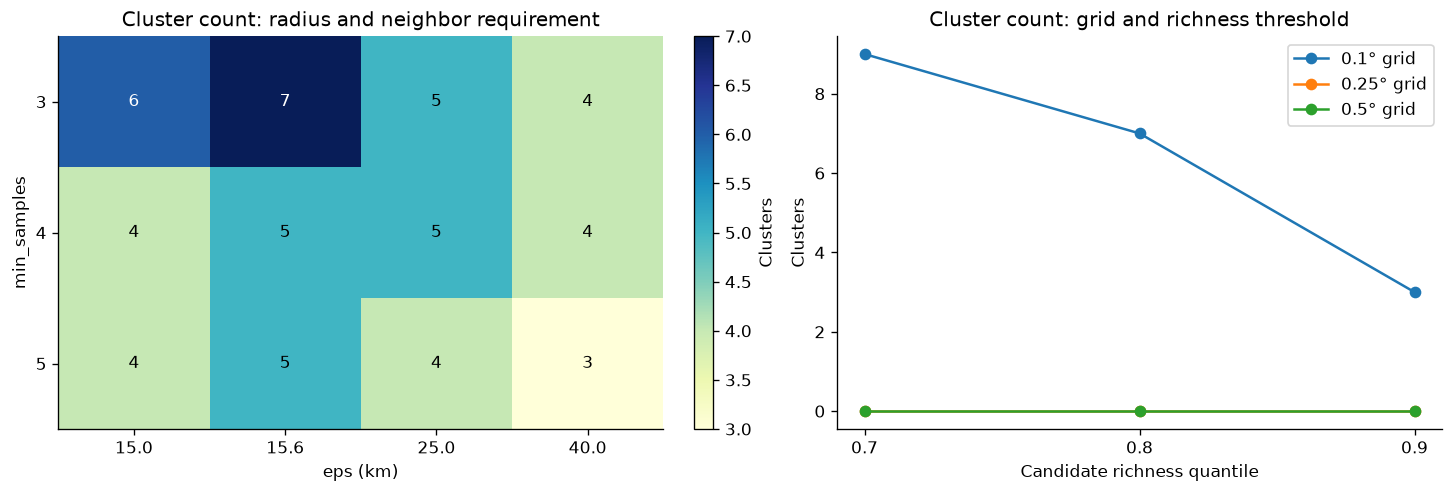

In [10]:
scale_trials = []
for step in [0.1, 0.25, 0.5]:
    _, cells_at_scale = aggregate_grid(df, step)
    for quantile in [0.7, 0.8, 0.9]:
        cut = cells_at_scale.unique_species.quantile(quantile)
        selected = cells_at_scale[cells_at_scale.unique_species >= cut]
        labels = run_dbscan(selected, EPS_KM, MIN_SAMPLES)
        scale_trials.append({'grid_degrees': step, 'quantile': quantile, 'occupied_cells': len(cells_at_scale), 'richness_cutoff': cut, 'candidate_cells': len(selected), **label_stats(labels)})
scale_sensitivity = pd.DataFrame(scale_trials)
print(scale_sensitivity.round(2).to_string(index=False))
scale_sensitivity.to_csv(OUTPUT / 'grid_threshold_sensitivity.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
matrix = sensitivity.pivot(index='min_samples', columns='eps_km', values='clusters')
im = axes[0].imshow(matrix, cmap='YlGnBu', aspect='auto')
axes[0].set_xticks(range(len(matrix.columns)), [f'{v:.1f}' for v in matrix.columns])
axes[0].set_yticks(range(len(matrix.index)), matrix.index)
axes[0].set(title='Cluster count: radius and neighbor requirement', xlabel='eps (km)', ylabel='min_samples')
for iy in range(matrix.shape[0]):
    for ix in range(matrix.shape[1]):
        value = matrix.iloc[iy, ix]
        label_color = 'white' if value > (matrix.to_numpy().max() + matrix.to_numpy().min()) / 2 else 'black'
        axes[0].text(ix, iy, str(value), ha='center', va='center', color=label_color)
fig.colorbar(im, ax=axes[0], label='Clusters')
for step, subset in scale_sensitivity.groupby('grid_degrees'):
    axes[1].plot(subset['quantile'], subset.clusters, marker='o', label=f'{step}° grid')
axes[1].set(title='Cluster count: grid and richness threshold', xlabel='Candidate richness quantile', ylabel='Clusters', xticks=[0.7, 0.8, 0.9])
axes[1].legend()
fig.savefig(OUTPUT / '07_sensitivity.png', bbox_inches='tight')
plt.show()


## 9. Draft interpretation generated from the actual results

The text below uses calculated values rather than hypothetical findings. Geographic names should be added only after examining cluster locations against a suitable boundary or gazetteer. A strong record–richness relationship means sampling coverage deserves attention; it does not quantify how much of the spatial pattern is ecological.


In [11]:
print(f'The cleaned Visayas-window snapshot contains {len(df):,} marine ray-finned fish records and {df.species_key.nunique():,} recorded species across {len(grid)} occupied {GRID_SIZE}° cells.')
print(f'{len(candidates)} cells meet the {RICHNESS_QUANTILE:.0%} richness quantile threshold ({threshold:.1f} species). At eps={EPS_KM:.2f} km and min_samples={MIN_SAMPLES}, DBSCAN identifies {len(cluster_ids)} clusters and {len(noise)} isolated candidate cells.')
print(f'Record count and cell richness have rank correlation {rho:.3f}. Interpret cluster richness alongside dataset counts, years sampled, and record counts.')
if len(cluster_summary):
    richest = cluster_summary.unique_species.idxmax()
    row = cluster_summary.loc[richest]
    top_families = cluster_records.loc[cluster_records.cluster == richest, 'family'].value_counts().head(3)
    print(f'Cluster {richest} has the largest species union: {int(row.unique_species):,} species from {int(row.total_records):,} records in {int(row.grid_cells)} candidate cells, contributed by {int(row.datasets)} datasets.')
    print('Its most frequently recorded families:', ', '.join(f'{name} ({count:,} records)' for name, count in top_families.items()))
    for cluster_id in cluster_summary.index:
        subset = cluster_records[cluster_records.cluster == cluster_id]
        family_counts = subset.family.value_counts()
        if len(family_counts):
            dominant = family_counts.index[0]
            share = 100 * family_counts.iloc[0] / len(subset)
            print(f'Cluster {cluster_id}: most frequently recorded family is {dominant} ({share:.1f}% of all its records). Differences in record composition may reflect habitat, survey methods, or source coverage.')
print(f'Tested parameter combinations produce {sensitivity.clusters.min()}–{sensitivity.clusters.max()} clusters. The pilot is parameter dependent; report this range with the map.')
print(f'Year coverage: {100*df.year.notna().mean():.1f}%; depth coverage: {100*df.depth_m.notna().mean():.1f}%. Neither annual totals nor depth differences establish ecological change or causation.')
if 'coordinateUncertaintyInMeters' in df:
    uncertainty = pd.to_numeric(df.coordinateUncertaintyInMeters, errors='coerce')
    print(f'{int((uncertainty > 10000).sum()):,} records have reported coordinate uncertainty above 10 km, close to the pilot grid width. Before finalizing, test their exclusion, check land locations, and retrieve missing OBIS quality flags. Unreported uncertainty is not evidence of precise coordinates.')


The cleaned Visayas-window snapshot contains 38,865 marine ray-finned fish records and 2,237 recorded species across 358 occupied 0.1° cells.
73 cells meet the 80% richness quantile threshold (31.0 species). At eps=15.63 km and min_samples=3, DBSCAN identifies 7 clusters and 17 isolated candidate cells.
Record count and cell richness have rank correlation 0.969. Interpret cluster richness alongside dataset counts, years sampled, and record counts.
Cluster 0 has the largest species union: 1,524 species from 19,484 records in 23 candidate cells, contributed by 16 datasets.
Its most frequently recorded families: Gobiidae (2,373 records), Labridae (2,066 records), Pomacentridae (1,899 records)
Cluster 0: most frequently recorded family is Gobiidae (12.2% of all its records). Differences in record composition may reflect habitat, survey methods, or source coverage.
Cluster 1: most frequently recorded family is Pomacentridae (19.5% of all its records). Differences in record composition may r

## 10. Limitations and route to the final project

- **Sampling bias:** records mix surveys, specimens, methods, datasets and historical periods. Dataset count and years are coverage indicators, not standardized effort. Presence-only records cannot estimate true richness without stronger assumptions.
- **Spatial scope and quality:** the rectangle is a pilot window; marine taxon status does not validate habitat or coordinates. Coarse, repeated, on-land or uncertain coordinates can create artificial concentrations. Check coordinate uncertainty, OBIS flags, and a defensible maritime/habitat boundary before finalizing.
- **Taxonomy and deduplication:** the pilot relies on OBIS taxonomic identifiers. Name fallbacks and duplicate occurrences across providers deserve review. Ray-finned fish are only one component of marine biodiversity.
- **Scale and clustering:** richness depends on cell size; candidate selection, ties, `eps`, and `min_samples` affect results. The elbow heuristic is a diagnostic, not a proof of optimal parameters. Count sensitivity does not guarantee stable cluster membership.
- **Temporal pooling:** species accumulated over decades need not coexist today. Annual record totals describe database coverage rather than biodiversity change.
- **Ecological interpretation:** these are clusters of **high recorded richness**. Unsampled cells are unknown, and noise cells may still be important. No conservation priority or definitive ecological hotspot is established by this pilot alone.

For the final assignment, select the official study extent after data inspection, review the main contributing datasets and licenses, audit suspicious coordinates, compare spatial membership across reasonable scales, and characterize clusters using species/family composition plus sampling coverage. Add depth analyses only when coverage is adequate and add biological trends only when comparable sampling supports them.

Suggested 5–10 minute presentation: research question and scope → real dataset and cleaning → sampling map beside richness map → candidate threshold and distance choice → cluster map and composition → sensitivity and limitations → conclusions supported by this snapshot.

All seven figures are exported to `outputs/`, with cleaned records, provider attribution, cleaning counts, grid metrics, candidate labels, cluster summaries, and sensitivity tables saved as CSV files.
